# Evolutionary Design Optimization of an Aircraft Configuration

A multi-objective optimization problem for the conceptual design of an aircraft using evolutionary algorithms. The aim is to generate aircraft configurations that reduce aerodynamic drag, provide sufficient fuel volume inside the wings, and maximize cargo capacity.

## 1. Problem Statement

The objective is to design an aircraft configuration using evolutionary algorithms. Each candidate solution represents a possible aircraft geometry described by a vector of design variables.

The aircraft should be optimized with respect to three main criteria:

1. Minimize aerodynamic drag.
2. Maximize the available fuel volume inside the wings.
3. Maximize the available cargo space.

These criteria are conflicting. For example, reducing drag may require thinner wings, but thinner wings reduce the internal fuel volume. Increasing cargo capacity may require a larger fuselage, but a larger fuselage may increase drag. The optimizer must therefore search for compromise solutions rather than a single perfect solution.

## 2. Design Variable Vector

Let the aircraft design be represented by the vector:

$$
x = \left[ b, S_w, AR, \Lambda, t_c, L_f, D_f, V_c, V_f, S_t, x_e \right]
$$

where:

- $b$ is the wing span;
- $S_w$ is the wing area;
- $AR$ is the wing aspect ratio;
- $\Lambda$ is the wing sweep angle;
- $t_c$ is the wing thickness-to-chord ratio;
- $L_f$ is the fuselage length;
- $D_f$ is the fuselage diameter;
- $V_c$ is the available cargo volume;
- $V_f$ is the fuel volume stored inside the wings;
- $S_t$ is the tail surface area;
- $x_e$ is the engine placement variable.

A simplified relation for the aspect ratio is:

$$
AR = \frac{b^2}{S_w}
$$

This relation can either be imposed as a constraint or used to compute $AR$ directly from $b$ and $S_w$.

## 3. Objective Functions

The aircraft design problem is formulated as a multi-objective optimization problem.

The first objective is to minimize the drag coefficient:

$$
\min f_1(x) = C_D(x)
$$

The second objective is to maximize the fuel volume inside the wings:

$$
\max f_2(x) = V_{fuel}(x)
$$

The third objective is to maximize the available cargo volume:

$$
\max f_3(x) = V_{cargo}(x)
$$

Since many evolutionary algorithms are formulated as minimization algorithms, the problem can be written as:

$$
\min F(x) = \left[ C_D(x), -V_{fuel}(x), -V_{cargo}(x) \right]
$$

where:

- $C_D(x)$ is the aerodynamic drag coefficient;
- $V_{fuel}(x)$ is the fuel volume stored inside the wings;
- $V_{cargo}(x)$ is the available cargo space.

## 4. Simplified Aerodynamic Model

A simplified drag model may be used during conceptual design:

$$
C_D(x) = C_{D0}(x) + C_{Di}(x)
$$

where $C_{D0}(x)$ is the zero-lift drag coefficient and $C_{Di}(x)$ is the induced drag coefficient.

The induced drag coefficient may be approximated as:

$$
C_{Di}(x) = \frac{C_L^2}{\pi e AR}
$$

where $C_L$ is the lift coefficient, $e$ is the Oswald efficiency factor, and $AR$ is the wing aspect ratio.

The lift coefficient can be approximated by:

$$
C_L = \frac{2W}{\rho V^2 S_w}
$$

where $W$ is the aircraft weight, $\rho$ is the air density, $V$ is the flight velocity, and $S_w$ is the wing area.

The drag force may be estimated as:

$$
D(x) = \frac{1}{2}\rho V^2 S_w C_D(x)
$$

## 5. Fuel Volume Model

The fuel volume stored in the wings depends on the wing geometry and the internal usable volume. A simplified approximation is:

$$
V_{fuel}(x) = k_f S_w \bar{c} t_c
$$

where $k_f$ is a fuel-volume efficiency coefficient, $S_w$ is the wing area, $\bar{c}$ is the mean aerodynamic chord, and $t_c$ is the wing thickness-to-chord ratio.

The mean aerodynamic chord may be approximated as:

$$
\bar{c} = \frac{S_w}{b}
$$

Therefore:

$$
V_{fuel}(x) = k_f S_w \left( \frac{S_w}{b} \right) t_c
$$

## 6. Cargo Volume Model

The cargo volume is mainly influenced by the fuselage geometry. A simplified model is:

$$
V_{cargo}(x) = k_c L_f D_f^2
$$

where $k_c$ is a cargo-space efficiency coefficient, $L_f$ is the fuselage length, and $D_f$ is the fuselage diameter.

A larger fuselage may increase cargo space, but it may also increase aerodynamic drag and structural weight.

## 7. Constraints

The aircraft design must satisfy aerodynamic, structural, stability, and capacity constraints.

### 7.1 Lift Constraint

The generated lift must be at least equal to the aircraft weight:

$$
L(x) \geq W(x)
$$

where:

$$
L(x) = \frac{1}{2}\rho V^2 S_w C_L
$$

### 7.2 Minimum Fuel Capacity

$$
V_{fuel}(x) \geq V_{fuel}^{min}
$$

### 7.3 Minimum Cargo Capacity

$$
V_{cargo}(x) \geq V_{cargo}^{min}
$$

### 7.4 Structural Constraint

$$
\sigma(x) \leq \sigma_{max}
$$

### 7.5 Wing Area Bounds

$$
S_w^{min} \leq S_w(x) \leq S_w^{max}
$$

### 7.6 Aspect Ratio Bounds

$$
AR^{min} \leq AR(x) \leq AR^{max}
$$

### 7.7 Stability Constraint

$$
SM(x) \geq SM_{min}
$$

where $SM(x)$ is the static margin.

## 8. Evolutionary Algorithm Formulation

An evolutionary algorithm can be used to solve this constrained multi-objective problem. Suitable algorithms include Genetic Algorithm, NSGA-II, Differential Evolution, Multi-Objective Particle Swarm Optimization, and Evolution Strategies.

Each individual in the population represents an aircraft design:

$$
P = \{x_1, x_2, \ldots, x_N\}
$$

where $N$ is the population size.

Each individual is evaluated using the objective vector:

$$
F(x_i) = \left[ C_D(x_i), -V_{fuel}(x_i), -V_{cargo}(x_i) \right]
$$

The evolutionary algorithm applies selection, crossover, mutation, and replacement operators in order to evolve better aircraft designs over multiple generations.

## 9. Constraint Handling

Constraints can be handled using a penalty function. The penalized objective can be written as:

$$
F_p(x) = F(x) + \lambda P(x)
$$

where $F_p(x)$ is the penalized objective vector, $F(x)$ is the original objective vector, $\lambda$ is a penalty coefficient, and $P(x)$ is the total constraint violation.

A possible total penalty function is:

$$
P(x) = \sum_{j=1}^{m} \max(0, g_j(x))^2
$$

where $g_j(x) \leq 0$ represents the $j$-th inequality constraint.

## 10. Pareto Optimality

Because the problem has multiple conflicting objectives, the final output should not be a single design, but a set of Pareto-optimal aircraft configurations.

A design $x_a$ dominates another design $x_b$ if:

$$
f_i(x_a) \leq f_i(x_b), \quad \forall i
$$

and:

$$
\exists j \text{ such that } f_j(x_a) < f_j(x_b)
$$

The set of non-dominated solutions forms the Pareto front:

$$
PF = \{x \in X \mid \nexists y \in X : y \prec x\}
$$

where $y \prec x$ means that $y$ dominates $x$.

### Explanation of Pareto optimality

In a multi-objective optimization problem, several objectives must be optimized at the same time. 
Since these objectives may conflict with each other, there is usually no single solution that is optimal 
for all objectives simultaneously.

Let a solution be represented by a vector of decision variables:

$$\mathbf{x} = (x_1, x_2, \ldots, x_n) \in \Omega,$$


where $\Omega$ is the feasible search space. The objective function is defined as:

$$\mathbf{f}(\mathbf{x}) = \left(f_1(\mathbf{x}), f_2(\mathbf{x}), \ldots, f_m(\mathbf{x})\right),$$


where $m$ is the number of objectives.

Assuming a minimization problem, a solution $\mathbf{x}^{(1)}$ is said to dominate another solution 
$\mathbf{x}^{(2)}$, written as:

$$\mathbf{x}^{(1)} \prec \mathbf{x}^{(2)},$$

if the following two conditions are satisfied:

$$f_i(\mathbf{x}^{(1)}) \leq f_i(\mathbf{x}^{(2)}), \quad \forall i \in \{1,2,\ldots,m\},$$


and

$$\exists j \in \{1,2,\ldots,m\} \text{ such that } f_j(\mathbf{x}^{(1)}) < f_j(\mathbf{x}^{(2)}).$$


In other words, $\mathbf{x}^{(1)}$ is at least as good as $\mathbf{x}^{(2)}$ in all objectives and strictly 
better in at least one objective.

A solution $\mathbf{x}^*$ is called Pareto optimal if there is no other feasible solution 
$\mathbf{x} \in \Omega$ that dominates it:

$$\nexists \mathbf{x} \in \Omega \text{ such that } \mathbf{x} \prec \mathbf{x}^*.$$


The set of all Pareto optimal solutions is called the Pareto set:

$$P^* = \left\{ \mathbf{x}^* \in \Omega \mid \nexists \mathbf{x} \in \Omega : \mathbf{x} \prec \mathbf{x}^* \right\}.$$


The image of the Pareto set in the objective space is called the Pareto front:

$$PF^* = \left\{ \mathbf{f}(\mathbf{x}^*) \mid \mathbf{x}^* \in P^* \right\}.$$

In the aircraft design problem, the Pareto front contains aircraft designs that represent different 
trade-offs between objectives such as minimizing drag, minimizing fuel volume in the wings, and 
maximizing cargo space. A design on the Pareto front cannot be improved in one objective without 
worsening at least one other objective.

## 11. Generic Evolutionary Algorithm Procedure

The evolutionary optimization process can be summarized as follows:

1. Initialize a population of aircraft designs.
2. Evaluate aerodynamic drag, fuel volume, and cargo volume for each design.
3. Check constraints and apply penalties if necessary.
4. Select the best individuals based on Pareto dominance and diversity.
5. Apply crossover to generate new aircraft designs.
6. Apply mutation to introduce geometric variation.
7. Replace part or all of the population with the new individuals.
8. Repeat the process until a stopping criterion is met.
9. Return the Pareto-optimal set of aircraft designs.

The stopping criterion may be:

$$
t \geq T_{max}
$$

or:

$$
\Delta PF \leq \varepsilon
$$

where $t$ is the current generation, $T_{max}$ is the maximum number of generations, $\Delta PF$ is the change in the Pareto front, and $\varepsilon$ is a convergence threshold.

## 12. Example Python Skeleton

The following code provides a minimal structure for evaluating candidate aircraft designs. This is not a full aerodynamic solver. It is a simplified conceptual model intended for optimization experiments.

In [1]:
import numpy as np

# Constants used in the simplified model
rho = 1.225          # air density at sea level [kg/m^3]
V = 230.0            # cruise speed [m/s]
e = 0.8              # Oswald efficiency factor
W = 7.0e5            # aircraft weight [N]
k_f = 0.45           # fuel volume efficiency coefficient
k_c = 0.60           # cargo volume efficiency coefficient

# Minimum requirements
V_fuel_min = 80.0    # minimum fuel volume [m^3]
V_cargo_min = 120.0  # minimum cargo volume [m^3]
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

In [2]:
def evaluate_aircraft(x):
    """
    Evaluate a simplified aircraft design.
    Design vector: x = [b, S_w, sweep, t_c, L_f, D_f]
    """
    b, S_w, sweep, t_c, L_f, D_f = x
    AR = b**2 / S_w
    C_L = 2 * W / (rho * V**2 * S_w)
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    C_Di = C_L**2 / (np.pi * e * AR)
    C_D = C_D0 + C_Di
    c_bar = S_w / b
    V_fuel = k_f * S_w * c_bar * t_c
    V_cargo = k_c * L_f * D_f**2
    return C_D, V_fuel, V_cargo, AR

In [3]:
def constraint_penalty(x):
    """Compute a simple penalty for constraint violations."""
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    b, S_w, sweep, t_c, L_f, D_f = x
    violations = [
        max(0, V_fuel_min - V_fuel),
        max(0, V_cargo_min - V_cargo),
        max(0, AR_min - AR),
        max(0, AR - AR_max),
        max(0, S_w_min - S_w),
        max(0, S_w - S_w_max),
    ]
    return sum(v**2 for v in violations)

In [4]:
def objective_function(x, penalty_weight=1e3):
    """
    Multi-objective function converted into a penalized vector.
    Objectives: minimize drag, maximize fuel volume, maximize cargo volume.
    """
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    penalty = constraint_penalty(x)
    return np.array([
        C_D + penalty_weight * penalty,
        -V_fuel + penalty_weight * penalty,
        -V_cargo + penalty_weight * penalty,
    ])

In [5]:
# Example candidate aircraft design
# x = [wing span, wing area, sweep angle, thickness-to-chord ratio, fuselage length, fuselage diameter]
x_example = np.array([42.0, 140.0, 25.0, 0.12, 38.0, 4.5])

C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x_example)
F = objective_function(x_example)

print("Example aircraft design:")
print(f"Drag coefficient C_D: {C_D:.5f}")
print(f"Fuel volume: {V_fuel:.2f} m^3")
print(f"Cargo volume: {V_cargo:.2f} m^3")
print(f"Aspect ratio: {AR:.2f}")
print(f"Objective vector: {F}")

Example aircraft design:
Drag coefficient C_D: 0.02149
Fuel volume: 25.20 m^3
Cargo volume: 461.70 m^3
Aspect ratio: 12.60
Objective vector: [3003040.02148882 3003014.8        3002578.3       ]


## 13. Final Problem Formulation

The complete problem can be stated as follows:

Design an aircraft configuration using evolutionary algorithms in order to minimize aerodynamic drag, maximize the fuel volume stored in the wings, and maximize the available cargo space. The problem is treated as a constrained multi-objective optimization task, where each candidate solution represents a complete aircraft geometry.

The final optimization problem is:

$$
\min F(x) = \left[ C_D(x), -V_{fuel}(x), -V_{cargo}(x) \right]
$$

subject to:

$$
L(x) \geq W(x)
$$

$$
V_{fuel}(x) \geq V_{fuel}^{min}
$$

$$
V_{cargo}(x) \geq V_{cargo}^{min}
$$

$$
\sigma(x) \leq \sigma_{max}
$$

$$
S_w^{min} \leq S_w(x) \leq S_w^{max}
$$

$$
AR^{min} \leq AR(x) \leq AR^{max}
$$

$$
SM(x) \geq SM_{min}
$$

The evolutionary algorithm should return a Pareto front of feasible aircraft designs, allowing the designer to choose an appropriate compromise between aerodynamic efficiency, fuel capacity, and cargo space.

## 14. Simple Evolutionary Algorithm Solution

The following cells contain the implementation and results. The detailed explanation is provided in the written report.


### Imports


In [16]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(7)
np.random.seed(7)

### Constants and Bounds


In [17]:
# Constants from the problem statement
rho = 1.225
V = 230.0
e = 0.8
W = 7.0e5
k_f = 0.45
k_c = 0.60

# Required constraints
V_fuel_min = 80.0
V_cargo_min = 120.0
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

# Design vector: [wing span, wing area, sweep, thickness ratio, fuselage length, fuselage diameter]
variable_names = ['b', 'S_w', 'sweep', 't_c', 'L_f', 'D_f']

bounds = np.array([
    [28.0, 70.0],      # b
    [80.0, 300.0],     # S_w
    [0.0, 35.0],       # sweep
    [0.08, 0.18],      # t_c
    [25.0, 65.0],      # L_f
    [3.0, 8.0],        # D_f
])

### Evaluation Functions


In [18]:
def evaluate_aircraft(x):
    b, S_w, sweep, t_c, L_f, D_f = x

    AR = b**2 / S_w
    C_L = 2 * W / (rho * V**2 * S_w)
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    C_Di = C_L**2 / (np.pi * e * AR)
    C_D = C_D0 + C_Di

    c_bar = S_w / b
    V_fuel = k_f * S_w * c_bar * t_c
    V_cargo = k_c * L_f * D_f**2

    return C_D, V_fuel, V_cargo, AR


def objective_values(x):
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    return np.array([C_D, -V_fuel, -V_cargo])


def constraint_penalty(x):
    """Returns 0 for feasible designs and a positive value for invalid designs."""
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    S_w = x[1]

    violations = [
        max(0, V_fuel_min - V_fuel),
        max(0, V_cargo_min - V_cargo),
        max(0, AR_min - AR),
        max(0, AR - AR_max),
        max(0, S_w_min - S_w),
        max(0, S_w - S_w_max),
    ]

    return sum(v**2 for v in violations)


def is_feasible(x):
    return constraint_penalty(x) == 0

### Evolutionary Operators


In [19]:
def random_individual():
    return np.array([random.uniform(low, high) for low, high in bounds])


def initialize_population(size):
    return [random_individual() for _ in range(size)]


def dominates(a, b):
    penalty_a = constraint_penalty(a)
    penalty_b = constraint_penalty(b)

    # Feasible solutions are preferred over infeasible ones.
    if penalty_a == 0 and penalty_b > 0:
        return True
    if penalty_a > 0 and penalty_b == 0:
        return False

    # If both are infeasible, prefer the one with smaller violation.
    if penalty_a > 0 and penalty_b > 0:
        return penalty_a < penalty_b

    # If both are feasible, use Pareto dominance.
    f_a = objective_values(a)
    f_b = objective_values(b)
    return np.all(f_a <= f_b) and np.any(f_a < f_b)


def tournament_selection(population):
    a, b = random.sample(population, 2)
    if dominates(a, b):
        return a
    if dominates(b, a):
        return b
    return a if constraint_penalty(a) <= constraint_penalty(b) else b


def crossover(parent1, parent2, probability=0.85):
    if random.random() > probability:
        return parent1.copy(), parent2.copy()

    alpha = random.random()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1
    return child1, child2


def mutate(x, probability=0.15, strength=0.07):
    child = x.copy()

    for i in range(len(child)):
        if random.random() < probability:
            variable_range = bounds[i, 1] - bounds[i, 0]
            child[i] += np.random.normal(0, strength * variable_range)
            child[i] = np.clip(child[i], bounds[i, 0], bounds[i, 1])

    return child

### Pareto Front and Replacement


In [20]:
def nondominated_solutions(population):
    front = []

    for candidate in population:
        dominated = False

        for other in population:
            if other is not candidate and dominates(other, candidate):
                dominated = True
                break

        if not dominated and is_feasible(candidate):
            front.append(candidate)

    return front


def crowding_distance(front):
    """Compute crowding distance for each solution in a Pareto front.

    Solutions at the boundary of each objective get infinite distance (always kept).
    Interior solutions get a score based on the gap between their neighbors in
    objective space. Larger distance = more isolated = more diversity contribution.
    """
    n = len(front)
    if n <= 2:
        return [float('inf')] * n

    obj_vals = np.array([objective_values(x) for x in front])
    n_obj = obj_vals.shape[1]
    distances = np.zeros(n)

    for m in range(n_obj):
        sorted_idx = np.argsort(obj_vals[:, m])
        distances[sorted_idx[0]] = float('inf')
        distances[sorted_idx[-1]] = float('inf')

        obj_range = obj_vals[sorted_idx[-1], m] - obj_vals[sorted_idx[0], m]
        if obj_range == 0:
            continue

        for i in range(1, n - 1):
            distances[sorted_idx[i]] += (
                obj_vals[sorted_idx[i + 1], m] - obj_vals[sorted_idx[i - 1], m]
            ) / obj_range

    return distances.tolist()


def fast_nondominated_sort(population):
    feasible = [x for x in population if is_feasible(x)]
    infeasible = sorted([x for x in population if not is_feasible(x)], key=constraint_penalty)

    fronts = []
    remaining = feasible[:]

    while remaining:
        front = []
        for candidate in remaining:
            dominated = False
            for other in remaining:
                if other is not candidate and dominates(other, candidate):
                    dominated = True
                    break
            if not dominated:
                front.append(candidate)
        fronts.append(front)
        front_ids = {id(x) for x in front}
        remaining = [x for x in remaining if id(x) not in front_ids]

    if infeasible:
        fronts.append(infeasible)

    return fronts


def create_next_generation(population, population_size):
    children = []

    while len(children) < population_size:
        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)
        child1, child2 = crossover(parent1, parent2)

        children.append(mutate(child1))
        if len(children) < population_size:
            children.append(mutate(child2))

    combined = population + children
    fronts = fast_nondominated_sort(combined)


    survivors = []
    for front in fronts:
        if len(survivors) + len(front) <= population_size:
            survivors.extend(front)
        else:
            needed = population_size - len(survivors)
            distances = crowding_distance(front)
            ranked = sorted(zip(distances, range(len(front))), key=lambda p: -p[0])
            survivors.extend(front[i] for _, i in ranked[:needed])
            break

    return survivors


### Run Algorithm


In [21]:
def run_algorithm(population_size=70, generations=60):
    population = initialize_population(population_size)
    history = []

    for generation in range(generations + 1):
        front = nondominated_solutions(population)
        feasible_count = sum(1 for x in population if is_feasible(x))

        if front:
            best_drag = min(evaluate_aircraft(x)[0] for x in front)
            best_fuel = max(evaluate_aircraft(x)[1] for x in front)
            best_cargo = max(evaluate_aircraft(x)[2] for x in front)
        else:
            best_drag = np.nan
            best_fuel = np.nan
            best_cargo = np.nan

        history.append({
            'generation': generation,
            'feasible_count': feasible_count,
            'pareto_count': len(front),
            'best_drag': best_drag,
            'best_fuel': best_fuel,
            'best_cargo': best_cargo,
        })

        if generation < generations:
            population = create_next_generation(population, population_size)

    return population, pd.DataFrame(history)


population, history = run_algorithm(population_size=70, generations=60)
pareto_front = nondominated_solutions(population)

print('Final feasible individuals:', sum(1 for x in population if is_feasible(x)))
print('Final Pareto front size:', len(pareto_front))
history.tail()

Final feasible individuals: 70
Final Pareto front size: 70


,generation,feasible_count,pareto_count,best_drag,best_fuel,best_cargo
56,56,70,70,0.018361,169.463787,2496.0
57,57,70,70,0.018361,169.463787,2496.0
58,58,70,70,0.018359,169.463787,2496.0
59,59,70,70,0.018353,169.463787,2496.0
60,60,70,70,0.018353,169.463787,2496.0


### Final Results Table


In [22]:
def make_results_table(front, max_rows=12):
    front = sorted(front, key=lambda x: evaluate_aircraft(x)[0])

    if len(front) > max_rows:
        indexes = np.linspace(0, len(front) - 1, max_rows).astype(int)
        front = [front[i] for i in indexes]

    rows = []
    for i, x in enumerate(front, start=1):
        C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
        rows.append({
            'id': i,
            'b': x[0],
            'S_w': x[1],
            'sweep': x[2],
            't_c': x[3],
            'L_f': x[4],
            'D_f': x[5],
            'AR': AR,
            'C_D': C_D,
            'V_fuel': V_fuel,
            'V_cargo': V_cargo,
            'penalty': constraint_penalty(x),
        })

    return pd.DataFrame(rows)


results = make_results_table(pareto_front)
results.round(4)

,id,b,S_w,sweep,t_c,L_f,D_f,AR,C_D,V_fuel,V_cargo,penalty
0,1,62.8317,300.0000,0.0000,0.1757,65.0000,6.3774,13.1594,0.0184,113.2316,1586.1934,0
1,2,63.3545,298.4355,0.0000,0.1756,65.0000,6.9200,13.4494,0.0184,111.0990,1867.5500,0
2,3,59.2559,299.5274,0.0223,0.1728,63.2355,6.4204,11.7227,0.0184,117.7293,1564.0022,0
3,4,57.9508,299.1767,0.0064,0.1725,64.2649,6.8051,11.2251,0.0184,119.8773,1785.6475,0
4,5,53.8723,299.1144,0.0000,0.1713,64.4638,6.9699,9.7027,0.0184,128.0262,1878.9580,0
5,6,49.9538,299.4774,0.0394,0.1767,65.0000,6.4992,8.3325,0.0185,142.7977,1647.3353,0
6,7,50.0177,300.0000,0.0000,0.1796,65.0000,7.0372,8.3392,0.0185,145.4518,1931.3555,0
7,8,50.7683,296.3813,0.0541,0.1680,64.8737,7.6708,8.6963,0.0185,130.7710,2290.3551,0
8,9,47.5130,299.7453,0.0000,0.1781,63.2514,7.2904,7.5313,0.0185,151.5284,2017.0642,0
9,10,46.4509,299.7849,0.0000,0.1800,64.9478,7.9937,7.1974,0.0185,156.7151,2490.0684,0


### Plots


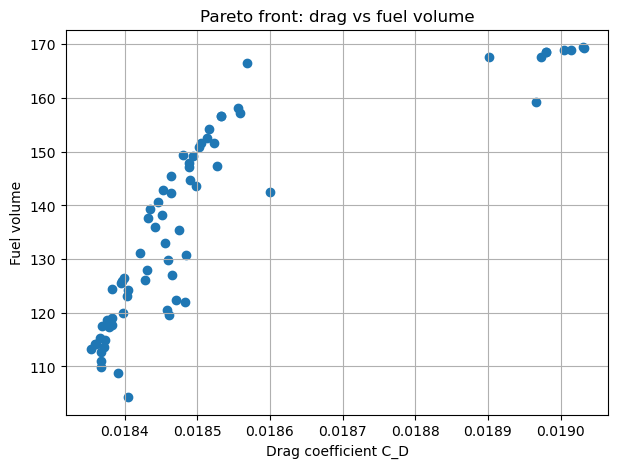

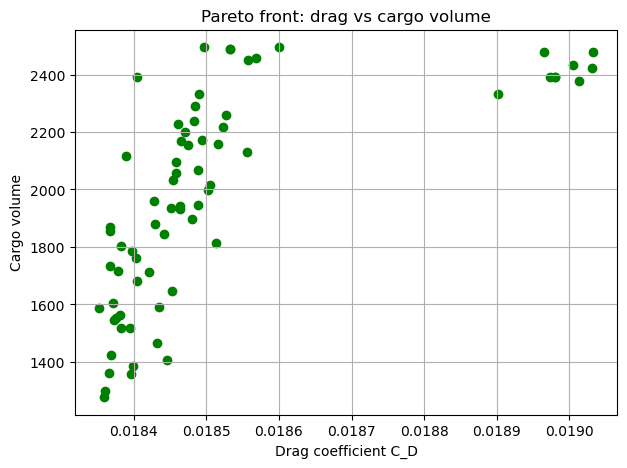

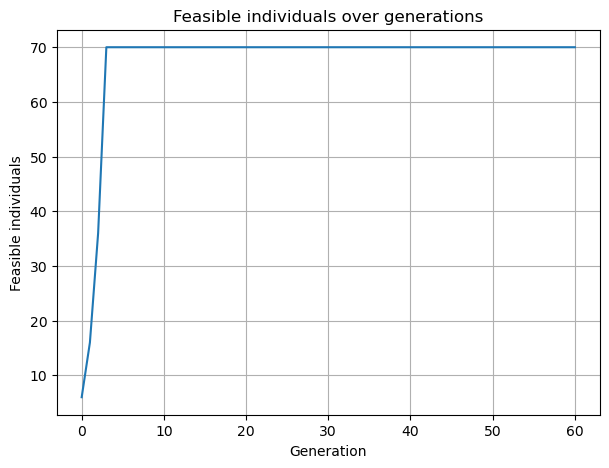

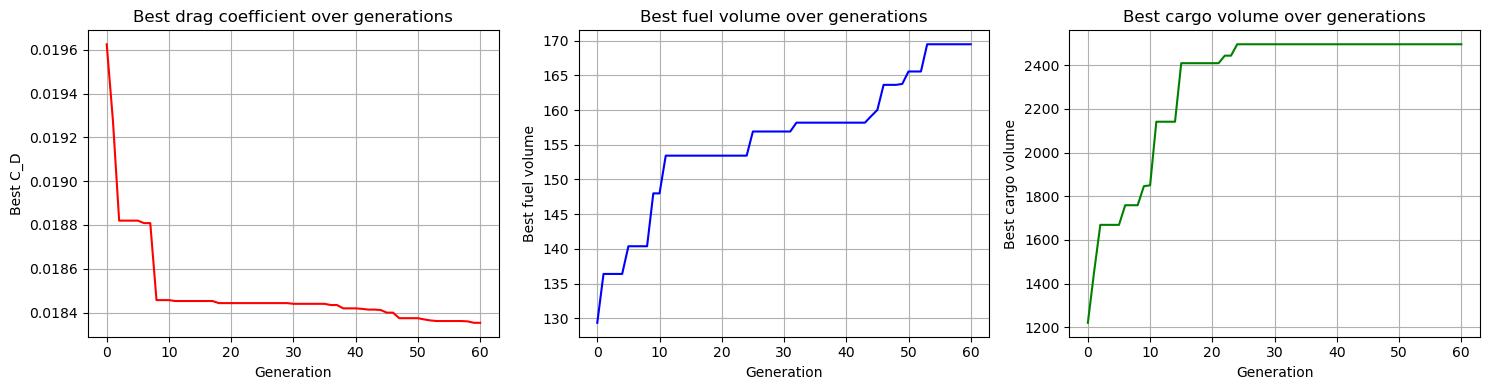

In [23]:
front_drag = [evaluate_aircraft(x)[0] for x in pareto_front]
front_fuel = [evaluate_aircraft(x)[1] for x in pareto_front]
front_cargo = [evaluate_aircraft(x)[2] for x in pareto_front]

plt.figure(figsize=(7, 5))
plt.scatter(front_drag, front_fuel)
plt.xlabel('Drag coefficient C_D')
plt.ylabel('Fuel volume')
plt.title('Pareto front: drag vs fuel volume')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(front_drag, front_cargo, color='green')
plt.xlabel('Drag coefficient C_D')
plt.ylabel('Cargo volume')
plt.title('Pareto front: drag vs cargo volume')
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history['generation'], history['feasible_count'])
plt.xlabel('Generation')
plt.ylabel('Feasible individuals')
plt.title('Feasible individuals over generations')
plt.grid(True)
plt.show()

# Convergence plots: best objective value found in the Pareto front at each generation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['generation'], history['best_drag'], color='red')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Best C_D')
axes[0].set_title('Best drag coefficient over generations')
axes[0].grid(True)

axes[1].plot(history['generation'], history['best_fuel'], color='blue')
axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Best fuel volume')
axes[1].set_title('Best fuel volume over generations')
axes[1].grid(True)

axes[2].plot(history['generation'], history['best_cargo'], color='green')
axes[2].set_xlabel('Generation')
axes[2].set_ylabel('Best cargo volume')
axes[2].set_title('Best cargo volume over generations')
axes[2].grid(True)

plt.tight_layout()
plt.show()
